<a href="https://colab.research.google.com/github/pattichis/AI4All/blob/main/Autoencoders.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

The material is adopted from:
[Chapter 18 – Autoencoders, GANs, and Diffusion Models](https://github.com/ageron/handson-mlp/blob/main/18_autoencoders_gans_and_diffusion_models.ipynb)


# Setup

This project requires Python 3.10 or above:

In [1]:
import sys

assert sys.version_info >= (3, 10)

Are we using Colab or Kaggle?

In [2]:
IS_COLAB = "google.colab" in sys.modules
IS_KAGGLE = "kaggle_secrets" in sys.modules

If using Colab, the TorchMetrics library is not pre-installed so we must install it manually:

In [3]:
if IS_COLAB:
    %pip install -q torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 16.0 MB/s eta 0:00:00


We also need PyTorch ≥ 2.6.0:

In [4]:
from packaging.version import Version
import torch

assert Version(torch.__version__) >= Version("2.6.0")

This chapter can be very slow without a hardware accelerator, so if we can find one, let's use it:

In [5]:
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

device

'cuda'

Let's issue a warning if there's no hardware accelerator available:

In [6]:
if device == "cpu":
    print("Neural nets can be very slow without a hardware accelerator.")
    if IS_COLAB:
        print("Go to Runtime > Change runtime and select a GPU hardware "
              "accelerator.")
    if IS_KAGGLE:
        print("Go to Settings > Accelerator and select GPU.")

As we did in earlier chapters, let's define the default font sizes to make the figures prettier:

In [7]:
import matplotlib.pyplot as plt

plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

We will also be using the same `train()` and `evaluate_tm()` functions as in previous chapters, but with a couple tweaks to the `train()` function:
* Gradient clipping using `torch.nn.utils.clip_grad_norm_()`
* Support for named tuples outputs containing an `output` field (see the lines: `y_pred = y_pred.output if...`)

In [8]:
import torchmetrics

def evaluate_tm(model, data_loader, metric):
    model.eval()
    metric.reset()
    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            if isinstance(y_pred, tuple):
                y_pred = y_pred.output
            metric.update(y_pred, y_batch)
    return metric.compute()

def train(model, optimizer, loss_fn, metric, train_loader, valid_loader,
          n_epochs, patience=2, factor=0.5, epoch_callback=None):
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="max", patience=patience, factor=factor)
    history = {"train_losses": [], "train_metrics": [], "valid_metrics": []}
    for epoch in range(n_epochs):
        total_loss = 0.0
        metric.reset()
        model.train()
        if epoch_callback is not None:
            epoch_callback(model, epoch)
        for index, (X_batch, y_batch) in enumerate(train_loader):
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            loss = loss_fn(y_pred, y_batch)
            total_loss += loss.item()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            optimizer.zero_grad()
            if isinstance(y_pred, tuple):
                y_pred = y_pred.output
            metric.update(y_pred, y_batch)
            train_metric = metric.compute().item()
            print(f"\rBatch {index + 1}/{len(train_loader)}", end="")
            print(f", loss={total_loss/(index+1):.4f}", end="")
            print(f", {train_metric=:.3f}", end="")
        history["train_losses"].append(total_loss / len(train_loader))
        history["train_metrics"].append(train_metric)
        val_metric = evaluate_tm(model, valid_loader, metric).item()
        history["valid_metrics"].append(val_metric)
        scheduler.step(val_metric)
        print(f"\rEpoch {epoch + 1}/{n_epochs},                      "
              f"train loss: {history['train_losses'][-1]:.4f}, "
              f"train metric: {history['train_metrics'][-1]:.3}, "
              f"valid metric: {history['valid_metrics'][-1]:.3}")
    return history

In [9]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

import numpy as np
import matplotlib.pyplot as plt
import torchmetrics

# Stacked Autoencoders

## Implementing a Stacked Autoencoder Using PyTorch

Let's build and train a stacked Autoencoder with 3 hidden layers and 1 output layer (i.e., 2 stacked Autoencoders).

In [10]:
torch.manual_seed(42)  # extra code – ensures reproducibility

stacked_encoder = nn.Sequential(
    nn.Flatten(),
    nn.Linear(1 * 28 * 28, 128), nn.ReLU(),
    nn.Linear(128, 32), nn.ReLU(),
)
stacked_decoder = nn.Sequential(
    nn.Linear(32, 128), nn.ReLU(),
    nn.Linear(128, 1 * 28 * 28), nn.Sigmoid(),
    nn.Unflatten(dim=1, unflattened_size=(1, 28, 28))
)
stacked_ae = nn.Sequential(stacked_encoder, stacked_decoder).to(device)

Let's load the fashion MNIST dataset, and split it into a training set, a validation set, and a test set:

In [11]:
import torchvision
import torchvision.transforms.v2 as T

toTensor = T.Compose([T.ToImage(), T.ToDtype(torch.float32, scale=True)])

train_and_valid_data = torchvision.datasets.FashionMNIST(
    root="datasets", train=True, download=True, transform=toTensor)
test_data = torchvision.datasets.FashionMNIST(
    root="datasets", train=False, download=True, transform=toTensor)

torch.manual_seed(42)
train_data, valid_data = torch.utils.data.random_split(
    train_and_valid_data, [55_000, 5_000])

100%|██████████| 26.4M/26.4M [00:01<00:00, 14.2MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 211kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.94MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 24.0MB/s]


# Assignment: Dataset questions
1. What is the difference between the function calls to `torchvision.datasets.FashionMNIST()` that differentiate the training from the testing dataset?
2. How many images are used for validation?
3. How many images are use for training?

In [12]:
from torch.utils.data import Dataset

class AutoencoderDataset(Dataset):
    def __init__(self, base_dataset):
        self.base_dataset = base_dataset

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, idx):
        x, _ = self.base_dataset[idx]
        return x, x

train_loader = DataLoader(AutoencoderDataset(train_data), batch_size=32,
                          shuffle=True)
valid_loader = DataLoader(AutoencoderDataset(valid_data), batch_size=32)
test_loader = DataLoader(AutoencoderDataset(test_data), batch_size=32)

In [13]:
optimizer = torch.optim.NAdam(stacked_ae.parameters(), lr=0.01)
mse = nn.MSELoss()
rmse = torchmetrics.MeanSquaredError(squared=False).to(device)
history = train(stacked_ae, optimizer, mse, rmse, train_loader, valid_loader,
                n_epochs=10)

Epoch 1/10,                      train loss: 0.0253, train metric: 0.159, valid metric: 0.144
Epoch 2/10,                      train loss: 0.0196, train metric: 0.14, valid metric: 0.142
Epoch 3/10,                      train loss: 0.0185, train metric: 0.136, valid metric: 0.134
Epoch 4/10,                      train loss: 0.0179, train metric: 0.134, valid metric: 0.133
Epoch 5/10,                      train loss: 0.0159, train metric: 0.126, valid metric: 0.126
Epoch 6/10,                      train loss: 0.0155, train metric: 0.125, valid metric: 0.126
Epoch 7/10,                      train loss: 0.0152, train metric: 0.123, valid metric: 0.124
Epoch 8/10,                      train loss: 0.0144, train metric: 0.12, valid metric: 0.121
Epoch 9/10,                      train loss: 0.0142, train metric: 0.119, valid metric: 0.121
Epoch 10/10,                      train loss: 0.0141, train metric: 0.119, valid metric: 0.12


## Visualizing the Reconstructions

This function processes a few validation images through the autoencoder and displays the original images and their reconstructions:

In [14]:
def plot_image(image):
    plt.imshow(image.permute(1, 2, 0).cpu(), cmap="binary")
    plt.axis("off")

def plot_reconstructions(model, images, n_images=5):
    images = images[:n_images]
    with torch.no_grad():
        y_pred = model(images.to(device))
    if isinstance(y_pred, tuple):
        y_pred = y_pred.output
    fig = plt.figure(figsize=(len(images) * 1.5, 3))
    for idx in range(len(images)):
        plt.subplot(2, len(images), 1 + idx)
        plot_image(images[idx])
        plt.subplot(2, len(images), 1 + len(images) + idx)
        plot_image(y_pred[idx])

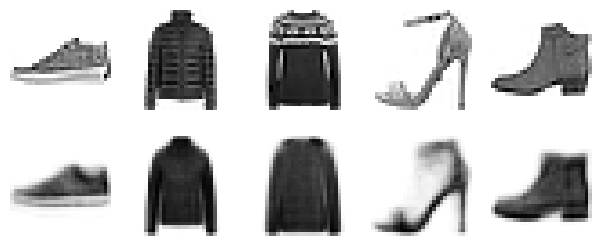

In [15]:
X_valid = torch.stack([x for x, _ in valid_data])
plot_reconstructions(stacked_ae, X_valid)

plt.show()

The reconstructions look fuzzy, but remember that the images were compressed down to just 32 numbers, instead of 784.

## Visualizing the Fashion MNIST Dataset

In [16]:
from sklearn.manifold import TSNE

with torch.no_grad():
    X_valid_compressed = stacked_encoder(X_valid.to(device))

tsne = TSNE(init="pca", learning_rate="auto", random_state=42)
X_valid_2D = tsne.fit_transform(X_valid_compressed.cpu())

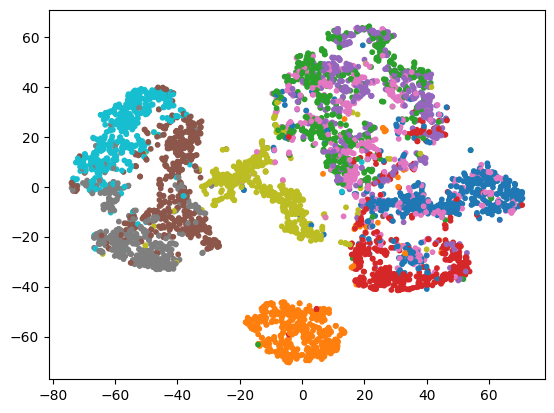

In [17]:
y_valid = torch.tensor([y for _, y in valid_data])

plt.scatter(X_valid_2D[:, 0], X_valid_2D[:, 1], c=y_valid, s=10, cmap="tab10")
plt.show()

Let's make this diagram a bit prettier (adapted from [this Scikit-Learn example](https://scikit-learn.org/stable/auto_examples/manifold/plot_lle_digits.html)):

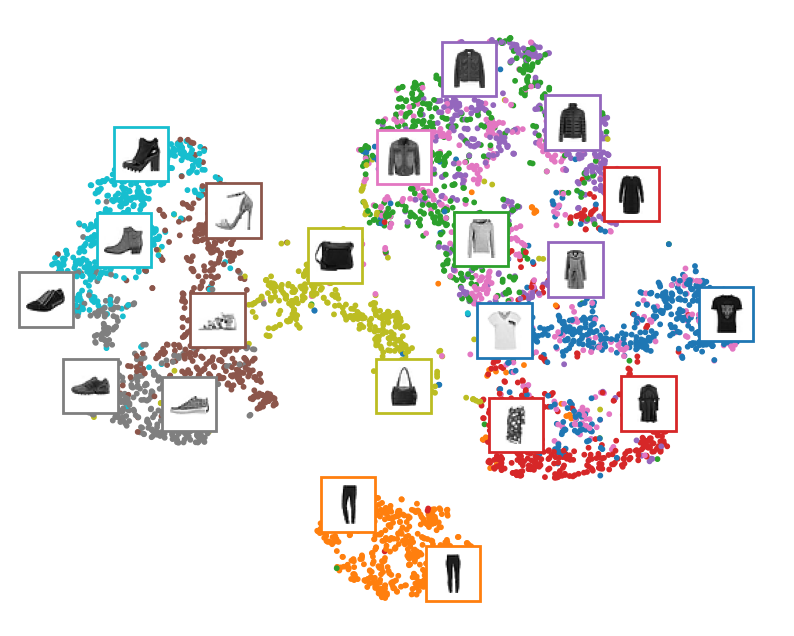

In [18]:
# extra code – beautifies the previous diagram for the book

import matplotlib as mpl

plt.figure(figsize=(10, 8))
cmap = plt.cm.tab10
Z = X_valid_2D
Z = (Z - Z.min()) / (Z.max() - Z.min())  # normalize to the 0-1 range
plt.scatter(Z[:, 0], Z[:, 1], c=y_valid, s=10, cmap=cmap)
image_positions = np.array([[1., 1.]])
for index, position in enumerate(Z):
    dist = ((position - image_positions) ** 2).sum(axis=1)
    if dist.min() > 0.02: # if far enough from other images
        image_positions = np.r_[image_positions, [position]]
        imagebox = mpl.offsetbox.AnnotationBbox(
            mpl.offsetbox.OffsetImage(X_valid[index].squeeze(dim=0),
                                      cmap="binary"),
            position, bboxprops={"edgecolor": cmap(y_valid[index]), "lw": 2})
        plt.gca().add_artist(imagebox)

plt.axis("off")

plt.show()

## Tying weights

It is common to tie the weights of the encoder and the decoder, by simply using the transpose of the encoder's weights as the decoder weights. For this, we can use a custom module.

In [19]:
import torch.nn.functional as F

class TiedAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc1 = nn.Linear(1 * 28 * 28, 128)
        self.enc2 = nn.Linear(128, 32)
        self.dec1_bias = nn.Parameter(torch.zeros(128))
        self.dec2_bias = nn.Parameter(torch.zeros(1 * 28 * 28))

    def encode(self, X):
        Z = X.view(-1, 1 * 28 * 28)  # flatten
        Z = F.relu(self.enc1(Z))
        return F.relu(self.enc2(Z))

    def decode(self, X):
        Z = F.relu(F.linear(X, self.enc2.weight.t(), self.dec1_bias))
        Z = F.sigmoid(F.linear(Z, self.enc1.weight.t(), self.dec2_bias))
        return Z.view(-1, 1, 28, 28)  # unflatten

    def forward(self, X):
        return self.decode(self.encode(X))

In [20]:
tied_ae = TiedAutoencoder().to(device)
optimizer = torch.optim.NAdam(tied_ae.parameters(), lr=0.01)
history = train(tied_ae, optimizer, mse, rmse, train_loader, valid_loader, n_epochs=10)

Epoch 1/10,                      train loss: 0.0229, train metric: 0.151, valid metric: 0.132
Epoch 2/10,                      train loss: 0.0173, train metric: 0.132, valid metric: 0.129
Epoch 3/10,                      train loss: 0.0167, train metric: 0.129, valid metric: 0.131
Epoch 4/10,                      train loss: 0.0161, train metric: 0.127, valid metric: 0.128
Epoch 5/10,                      train loss: 0.0141, train metric: 0.119, valid metric: 0.12
Epoch 6/10,                      train loss: 0.0138, train metric: 0.118, valid metric: 0.12
Epoch 7/10,                      train loss: 0.0136, train metric: 0.117, valid metric: 0.117
Epoch 8/10,                      train loss: 0.0128, train metric: 0.113, valid metric: 0.115
Epoch 9/10,                      train loss: 0.0127, train metric: 0.113, valid metric: 0.113
Epoch 10/10,                      train loss: 0.0126, train metric: 0.112, valid metric: 0.113


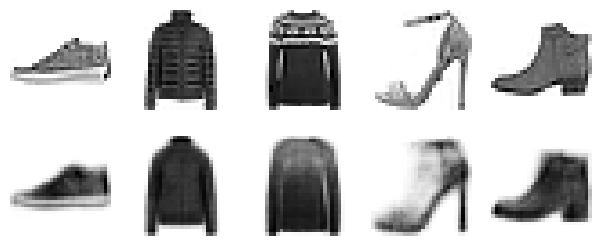

In [21]:
# extra code – plots reconstructions
plot_reconstructions(tied_ae, X_valid)
plt.show()

## Convolutional Autoencoders

Let's build a stacked Autoencoder with 3 hidden layers and 1 output layer (i.e., 2 stacked Autoencoders).

In [22]:
torch.manual_seed(42)  # extra code – ensures reproducibility

conv_encoder = nn.Sequential(
    nn.Conv2d(1, 16, kernel_size=3, padding="same"), nn.ReLU(),
    nn.MaxPool2d(kernel_size=2),  # output: 16 × 14 × 14
    nn.Conv2d(16, 32, kernel_size=3, padding="same"), nn.ReLU(),
    nn.MaxPool2d(kernel_size=2),  # output: 32 × 7 × 7
    nn.Conv2d(32, 64, kernel_size=3, padding="same"), nn.ReLU(),
    nn.MaxPool2d(kernel_size=2),  # output: 64 × 3 × 3
    nn.Conv2d(64, 32, kernel_size=3, padding="same"), nn.ReLU(),
    nn.AdaptiveAvgPool2d((1, 1)), nn.Flatten())  # output: 32

conv_decoder = nn.Sequential(
    nn.Linear(32, 16 * 3 * 3),
    nn.Unflatten(dim=1, unflattened_size=(16, 3, 3)),
    nn.ConvTranspose2d(16, 32, kernel_size=3, stride=2), nn.ReLU(),
    nn.ConvTranspose2d(32, 16, kernel_size=3, stride=2, padding=1,
                       output_padding=1), nn.ReLU(),
    nn.ConvTranspose2d(16, 1, kernel_size=3, stride=2, padding=1,
                       output_padding=1), nn.Sigmoid())

conv_ae = nn.Sequential(conv_encoder, conv_decoder).to(device)

In [23]:
optimizer = torch.optim.NAdam(conv_ae.parameters(), lr=0.005)
history = train(conv_ae, optimizer, mse, rmse, train_loader, valid_loader,
                n_epochs=10)

Epoch 1/10,                      train loss: 0.0291, train metric: 0.171, valid metric: 0.136
Epoch 2/10,                      train loss: 0.0171, train metric: 0.131, valid metric: 0.135
Epoch 3/10,                      train loss: 0.0149, train metric: 0.122, valid metric: 0.118
Epoch 4/10,                      train loss: 0.0137, train metric: 0.117, valid metric: 0.118
Epoch 5/10,                      train loss: 0.0124, train metric: 0.111, valid metric: 0.111
Epoch 6/10,                      train loss: 0.0121, train metric: 0.11, valid metric: 0.112
Epoch 7/10,                      train loss: 0.0119, train metric: 0.109, valid metric: 0.11
Epoch 8/10,                      train loss: 0.0115, train metric: 0.107, valid metric: 0.108
Epoch 9/10,                      train loss: 0.0114, train metric: 0.107, valid metric: 0.107
Epoch 10/10,                      train loss: 0.0113, train metric: 0.106, valid metric: 0.107


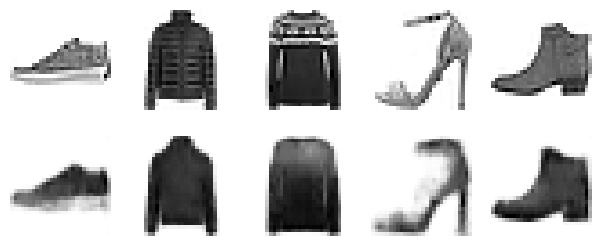

In [24]:
# extra code – shows the reconstructions
plot_reconstructions(conv_ae, X_valid)
plt.show()